# IPL Analysis (2008–2024)

## Business Problem
IPL teams, broadcasters, and sponsors make high-stakes decisions with limited analytical backing. 
This analysis answers key questions about team performance, venues, match strategy, and player impact.

## Dataset
- matches.csv: 1,095 matches, 20 columns
- deliveries.csv: 260,920 deliveries, 17 columns
- Source: Kaggle — IPL Complete Dataset by Prateek Bhardwaj

## Key Findings (Summary)
1. Mumbai Indians are the most successful team with 144 wins across 17 seasons
2. Chasing teams win more often than batting first (578 vs 498 matches)
3. AB de Villiers leads Player of Match awards with 25
4. Eden Gardens and Wankhede are the most used venues
5. 2013 had the most matches played (76)

In [55]:
import pandas as pd

matches = pd.read_csv('/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/matches.csv')
deliveries = pd.read_csv('/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

print("\nMatches columns:", matches.columns.tolist())
print("Deliveries columns:", deliveries.columns.tolist())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [57]:
print("Matches nulls:")
print(matches.isnull().sum())

print("\nDeliveries nulls:")
print(deliveries.isnull().sum())

Matches nulls:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Deliveries nulls:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [58]:
matches['city'] = matches['city'].fillna('Unknown')
print(matches.isnull().sum())

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [59]:
ipl = deliveries.merge(matches, left_on='match_id', right_on='id', how='left')
print("Merged shape:", ipl.shape)
print("Columns:", ipl.columns.tolist())

Merged shape: (260920, 37)
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [60]:
top_team = matches['winner'].value_counts().head(10)

print("Top 10 teams with most match wins:\n")
print(top_team)

Top 10 teams with most match wins:

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


In [61]:
most_matches_hosted_venue = matches['venue'].value_counts().head(10)

print("Top 10 most matches hosted venues:\n")
print(most_matches_hosted_venue)

Top 10 most matches hosted venues:

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


In [62]:
bat_first_wins = (matches['result'] == 'runs').sum()
chasing_wins = (matches['result'] == 'wickets').sum()

print("Batting first wins:", bat_first_wins)
print("Chasing wins:", chasing_wins)

Batting first wins: 498
Chasing wins: 578


In [63]:
most_player_of_match_awards = matches['player_of_match'].value_counts().head(10)

print("Top 10 players with most player of match award:\n")
print(most_player_of_match_awards)

Top 10 players with most player of match award:

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


In [64]:
season_with_most_matches = matches['season'].value_counts().head(10)

print("Top 10 seasons with most matches played:\n")
print(season_with_most_matches)

Top 10 seasons with most matches played:

season
2013       76
2022       74
2012       74
2023       74
2011       73
2024       71
2019       60
2016       60
2009/10    60
2021       60
Name: count, dtype: int64


In [65]:
death_overs = ipl[ipl['over'] >= 16]
print(death_overs.shape)

(46584, 37)


---
## Project Analysis — Business Questions

## Question 1: Death Over Bowling Economy
Which bowlers are most economical in death overs (overs 16–20) across IPL seasons?

In [66]:
# Group by bowler
bowler_stats = death_overs.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count')
)

# Convert balls to overs
bowler_stats['overs'] = bowler_stats['balls_bowled'] / 6

# Calculate economy rate
bowler_stats['economy'] = bowler_stats['runs_conceded'] / bowler_stats['overs']

# Optional but important: filter serious bowlers
bowler_stats = bowler_stats[bowler_stats['overs'] >= 10]

bowler_stats['overs'] = bowler_stats['overs'].round(1)
bowler_stats['economy'] = bowler_stats['economy'].round(2)

# Sort by economy (lowest is best)
top_bowlers = bowler_stats.sort_values('economy').head(10)

print(top_bowlers)

               runs_conceded  balls_bowled  overs  economy
bowler                                                    
M Theekshana              74            66   11.0     6.73
Sohail Tanvir            110            98   16.3     6.73
M Ashwin                  95            77   12.8     7.40
DE Bollinger             268           216   36.0     7.44
KH Pandya                123            96   16.0     7.69
Rashid Khan              408           315   52.5     7.77
SL Malinga              1252           965  160.8     7.78
A Kumble                 148           112   18.7     7.93
SP Narine               1003           755  125.8     7.97
M Pathirana              300           225   37.5     8.00


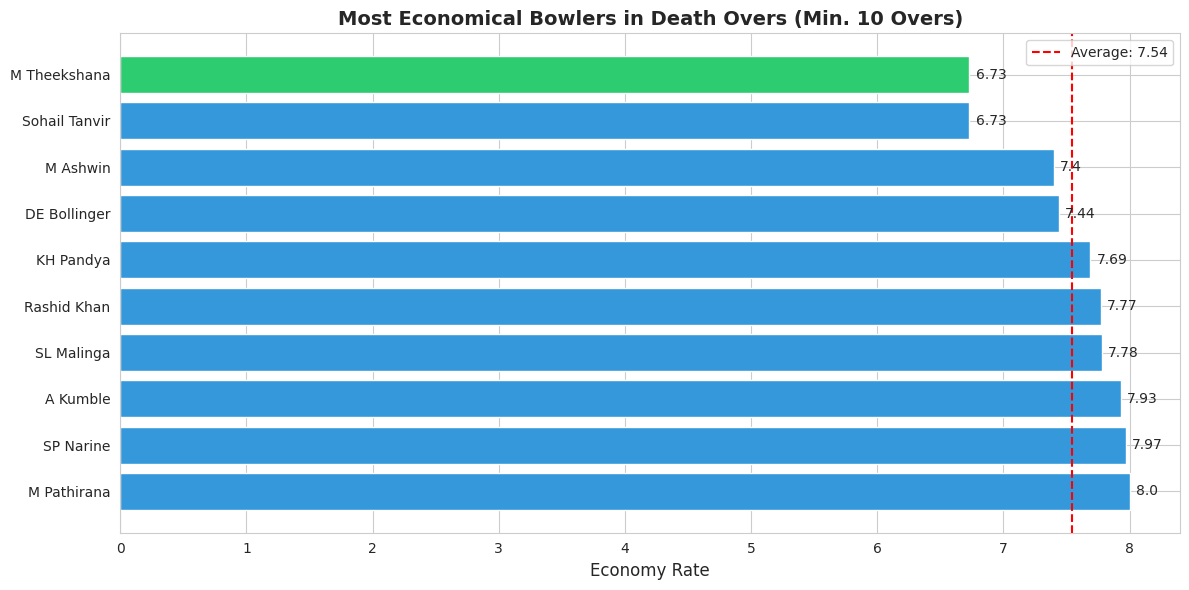

In [67]:
top_bowlers_plot = bowler_stats.sort_values('economy').head(10).reset_index()

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(top_bowlers_plot))]
bars = plt.barh(top_bowlers_plot['bowler'], top_bowlers_plot['economy'], color=colors)
plt.xlabel('Economy Rate', fontsize=12)
plt.title('Most Economical Bowlers in Death Overs (Min. 10 Overs)', fontsize=14, fontweight='bold')
plt.axvline(x=top_bowlers_plot['economy'].mean(), color='red', linestyle='--', 
            label=f'Average: {top_bowlers_plot["economy"].mean():.2f}')
plt.legend()
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_bowlers_plot['economy']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{val}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('death_over_bowling.png', dpi=150, bbox_inches='tight')
plt.show()

M Theekshana is the most reliable death over bowler with the lowest economy of 6.73 among bowlers with a minimum of 10 overs in death situations. Death over bowling is crucial in T20 cricket, the wrong bowler can concede 5-10 extra runs, which directly impacts match results. Teams can use this analysis to identify and prioritize proven death over specialists during auction and match selection.

## Question 2: Optimal Batting Order by Phase
What batting positions and player types perform best in powerplay (1–6), middle overs (7–15), and death overs (16–20)?

In [68]:
def get_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

ipl['phase'] = ipl['over'].apply(get_phase)

phase_batting = ipl.groupby(['phase', 'batter']).agg(
    runs=('batsman_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()

phase_batting['strike_rate'] = (phase_batting['runs'] / phase_batting['balls'] * 100).round(2)
phase_batting = phase_batting[phase_batting['balls'] >= 60]

top_per_phase = phase_batting.sort_values('strike_rate', ascending=False).groupby('phase').head(5)
print(top_per_phase.sort_values(['phase', 'strike_rate'], ascending=[True, False]))

          phase           batter  runs  balls  strike_rate
529       Death         T Stubbs   233     85       274.12
24        Death   AB de Villiers  1421    635       223.78
301       Death       MA Agarwal   188     86       218.60
513       Death   Shashank Singh   158     75       210.67
87        Death      BB McCullum   158     78       202.56
1113     Middle         WG Jacks   139     67       207.46
937      Middle          PD Salt   190    109       174.31
1100     Middle         V Sehwag   910    534       170.41
1041     Middle        SP Narine   448    264       169.70
980      Middle       RM Patidar   542    332       163.25
1256  Powerplay  J Fraser-McGurk   292    122       239.34
1469  Powerplay          TM Head   473    245       193.06
1368  Powerplay          PD Salt   439    265       165.66
1436  Powerplay        SP Narine   993    618       160.68
1169  Powerplay  Abhishek Sharma   839    552       151.99


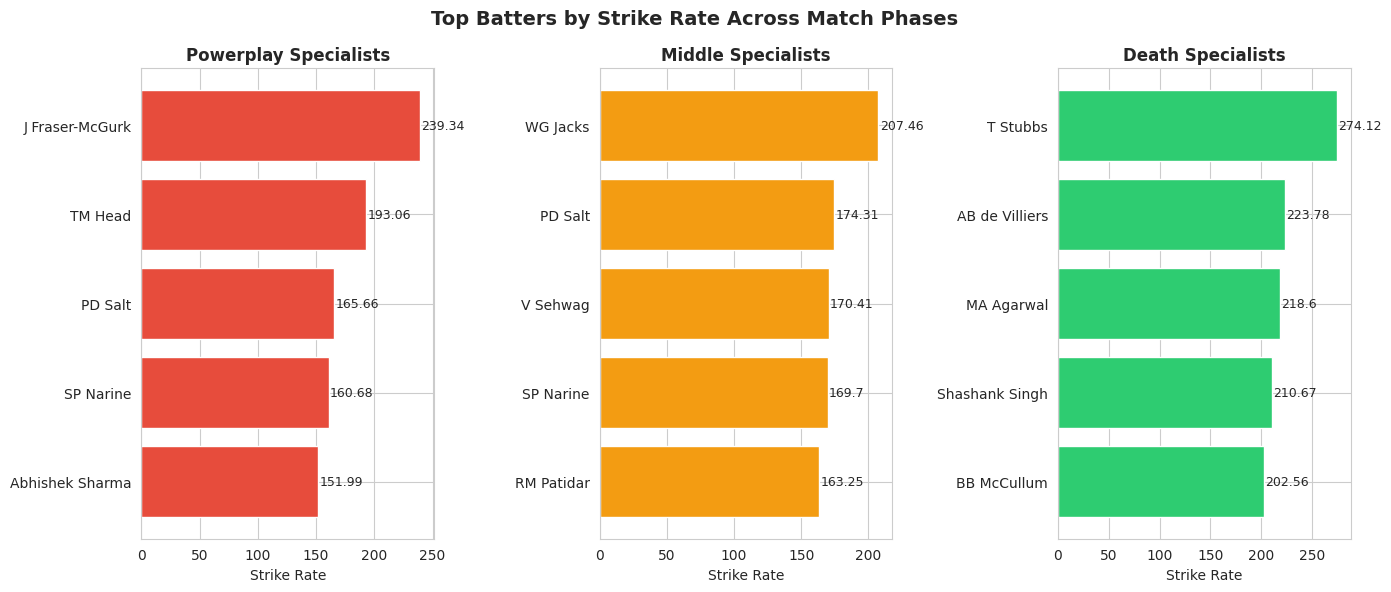

In [69]:
top_per_phase_plot = phase_batting.sort_values('strike_rate', ascending=False).groupby('phase').head(5).reset_index()

plt.figure(figsize=(14, 6))
colors_phase = {'Powerplay': '#e74c3c', 'Middle': '#f39c12', 'Death': '#2ecc71'}

for i, phase in enumerate(['Powerplay', 'Middle', 'Death']):
    subset = top_per_phase_plot[top_per_phase_plot['phase'] == phase].sort_values('strike_rate', ascending=False)
    plt.subplot(1, 3, i+1)
    bars = plt.barh(subset['batter'], subset['strike_rate'], color=colors_phase[phase])
    plt.xlabel('Strike Rate')
    plt.title(f'{phase} Specialists', fontweight='bold')
    plt.gca().invert_yaxis()
    for bar, val in zip(bars, subset['strike_rate']):
        plt.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

plt.suptitle('Top Batters by Strike Rate Across Match Phases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('batting_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

AB de Villiers is the most reliable death over batsmen with a strike rate of 223.78 among batters, and T Stubbs has the highest strike rate of 274.12, but he faced only 85 balls, whereas AB de Villiers faced 635 balls, which makes him the best finisher in this league. Also, V Sehwag, along with SP Narine, has the highest strike rates in the middle overs and powerplay in terms of balls faced. Selecting a good batter with a decent Strike rate is crucial in T20 cricket — the wrong batter can score 20-30 fewer runs, which directly impacts match results. Teams can use this analysis to identify and prioritize proven batters according to overs.

## Question 3: Match Conditions Producing Most Engaging Games
Which venues and match conditions produce the most close finishes and high-pressure moments?

In [70]:
# Define close finishes - wins by small margins
bat_first_close = matches[
    (matches['result'] == 'runs') & 
    (matches['result_margin'] <= 10)
].shape[0]

chase_close = matches[
    (matches['result'] == 'wickets') & 
    (matches['result_margin'] <= 2)
].shape[0]

super_overs = matches[matches['super_over'] == 'Y'].shape[0]

print(f"Close wins batting first (<=10 runs): {bat_first_close}")
print(f"Close wins chasing (<=2 wickets): {chase_close}")
print(f"Super over matches: {super_overs}")

# Which venues produce most close finishes
close_matches = matches[
    ((matches['result'] == 'runs') & (matches['result_margin'] <= 10)) |
    ((matches['result'] == 'wickets') & (matches['result_margin'] <= 2))
]
print("\nVenues with most close finishes:")
print(close_matches['venue'].value_counts().head(10))

Close wins batting first (<=10 runs): 121
Close wins chasing (<=2 wickets): 14
Super over matches: 14

Venues with most close finishes:
venue
Wankhede Stadium                            12
Eden Gardens                                11
Feroz Shah Kotla                             9
MA Chidambaram Stadium, Chepauk              8
Kingsmead                                    5
Dubai International Cricket Stadium          5
MA Chidambaram Stadium, Chepauk, Chennai     5
Wankhede Stadium, Mumbai                     4
Rajiv Gandhi International Stadium           4
Eden Gardens, Kolkata                        4
Name: count, dtype: int64


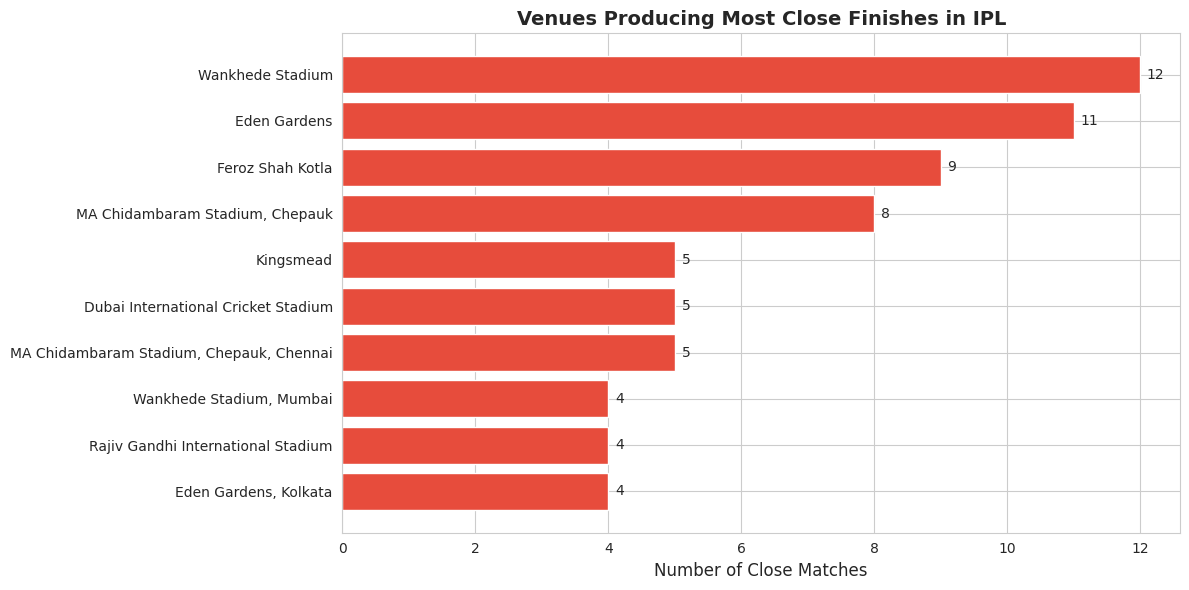

In [71]:
close_venues = close_matches['venue'].value_counts().head(10).reset_index()
close_venues.columns = ['venue', 'close_matches']

plt.figure(figsize=(12, 6))
bars = plt.barh(close_venues['venue'], close_venues['close_matches'], color='#e74c3c')
plt.xlabel('Number of Close Matches', fontsize=12)
plt.title('Venues Producing Most Close Finishes in IPL', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, close_venues['close_matches']):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('close_finishes_venues.png', dpi=150, bbox_inches='tight')
plt.show()

According to this, we can see that the possibility of giving a tough fight is more possible for the teams who bats first and set the target. Among the 135 close encounters, the team that batted first won 121 times. Among those, Wankhede has hosted 16 matches, and Eden Gardens has hosted 15 matches.

## Question 4: Player & Team Visibility During Key Moments
Which players and teams generate the highest visibility during death overs for broadcasters and sponsors?

In [72]:
# Most impactful players in death overs (high runs + wickets)
death_batting = ipl[ipl['phase'] == 'Death'].groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()
death_batting = death_batting[death_batting['balls'] >= 60]
death_batting['strike_rate'] = (death_batting['runs'] / death_batting['balls'] * 100).round(2)

death_bowling = ipl[ipl['phase'] == 'Death'].groupby('bowler').agg(
    wickets=('is_wicket', 'sum'),
    runs_conceded=('total_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()
death_bowling = death_bowling[death_bowling['balls'] >= 60]

print("Top 10 batters in death overs by runs scored:")
print(death_batting.sort_values('runs', ascending=False).head(10))

print("\nTop 10 bowlers in death overs by wickets:")
print(death_bowling.sort_values('wickets', ascending=False).head(10))

Top 10 batters in death overs by runs scored:
             batter  runs  balls  strike_rate
328        MS Dhoni  2786   1556       179.05
242      KA Pollard  1708    994       171.83
247      KD Karthik  1565    881       177.64
24   AB de Villiers  1421    635       223.78
415       RA Jadeja  1420    931       152.52
421       RG Sharma  1176    625       188.16
182       HH Pandya  1126    654       172.17
550         V Kohli  1099    571       192.47
31       AD Russell  1065    570       186.84
124       DA Miller   988    576       171.53

Top 10 bowlers in death overs by wickets:
             bowler  wickets  runs_conceded  balls
95         DJ Bravo      115           1842   1179
341      SL Malinga      104           1252    965
58          B Kumar       93           1884   1231
151       JJ Bumrah       89           1601   1163
124        HV Patel       74           1069    664
228       MM Sharma       72           1142    692
238  Mohammed Shami       69           1030    5

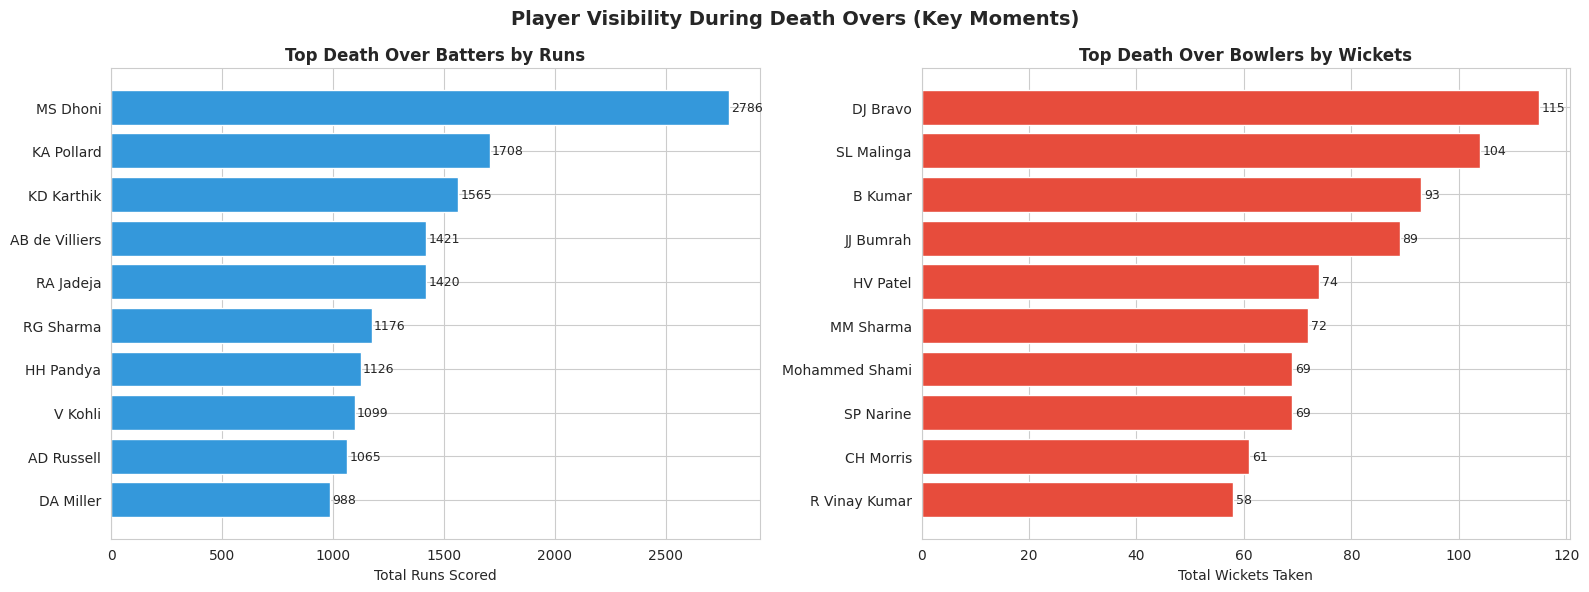

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top death over batters by runs
top_death_bat = death_batting.sort_values('runs', ascending=False).head(10).reset_index()
bars1 = ax1.barh(top_death_bat['batter'], top_death_bat['runs'], color='#3498db')
ax1.set_xlabel('Total Runs Scored')
ax1.set_title('Top Death Over Batters by Runs', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, top_death_bat['runs']):
    ax1.text(val + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

# Top death over bowlers by wickets
top_death_bowl = death_bowling.sort_values('wickets', ascending=False).head(10).reset_index()
bars2 = ax2.barh(top_death_bowl['bowler'], top_death_bowl['wickets'], color='#e74c3c')
ax2.set_xlabel('Total Wickets Taken')
ax2.set_title('Top Death Over Bowlers by Wickets', fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars2, top_death_bowl['wickets']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.suptitle('Player Visibility During Death Overs (Key Moments)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('player_visibility.png', dpi=150, bbox_inches='tight')
plt.show()

Players like MS Dhoni, AB de Villiers, Dwayne Bravo, and Jasprit Bumrah are highly valuable for broadcasters and sponsors because death overs generate the highest excitement, viewership, and advertising attention in T20 cricket. Their ability to score quickly or take crucial wickets during the final overs directly increases audience engagement and makes them strong commercial and branding assets.

## Question 5: Pressure & Performance
How does player performance shift in knockout matches compared to regular league games?

In [74]:
# Compare player performance in knockout vs league matches
knockout = ipl[ipl['match_type'].isin(['Final', 'Semi Final', 'Qualifier', 'Eliminator'])]
league = ipl[ipl['match_type'] == 'League']

knockout_batting = knockout.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()
knockout_batting['strike_rate'] = (knockout_batting['runs'] / knockout_batting['balls'] * 100).round(2)
knockout_batting = knockout_batting[knockout_batting['balls'] >= 30]

league_batting = league.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()
league_batting['strike_rate'] = (league_batting['runs'] / league_batting['balls'] * 100).round(2)
league_batting = league_batting[league_batting['balls'] >= 100]

print("Top 10 batters by strike rate in KNOCKOUT matches:")
print(knockout_batting.sort_values('strike_rate', ascending=False).head(10))

print("\nTop 10 batters by strike rate in LEAGUE matches:")
print(league_batting.sort_values('strike_rate', ascending=False).head(10))

Top 10 batters by strike rate in KNOCKOUT matches:
              batter  runs  balls  strike_rate
20   B Sai Sudharsan    96     48       200.00
87        KA Pollard   227    114       199.12
169       RM Patidar   146     78       187.18
25          BJ Hodge    54     31       174.19
124         MS Bisla    89     52       171.15
7       AC Gilchrist   100     59       169.49
172          RR Pant   105     62       169.35
184      SA Asnodkar    67     41       163.41
224          WP Saha   182    112       162.50
228        YK Pathan   183    114       160.53

Top 10 batters by strike rate in LEAGUE matches:
              batter  runs  balls  strike_rate
233  J Fraser-McGurk   330    150       220.00
648         WG Jacks   230    133       172.93
614          TM Head   738    427       172.83
431          PD Salt   653    385       169.61
603         T Stubbs   405    239       169.46
207        H Klaasen   877    520       168.65
39        AD Russell  2420   1470       164.63
609   

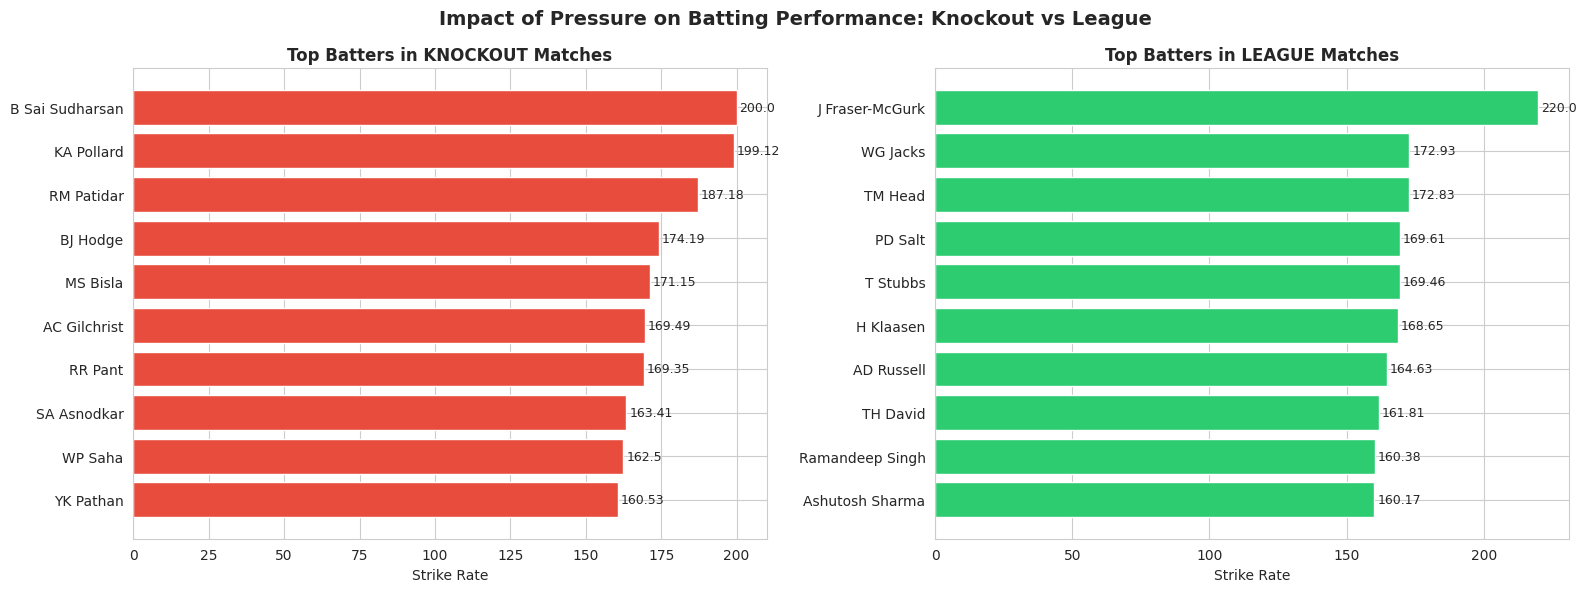

In [75]:
knockout_top = knockout_batting.sort_values('strike_rate', ascending=False).head(10).reset_index()
league_top = league_batting.sort_values('strike_rate', ascending=False).head(10).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bars1 = ax1.barh(knockout_top['batter'], knockout_top['strike_rate'], color='#e74c3c')
ax1.set_xlabel('Strike Rate')
ax1.set_title('Top Batters in KNOCKOUT Matches', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, knockout_top['strike_rate']):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

bars2 = ax2.barh(league_top['batter'], league_top['strike_rate'], color='#2ecc71')
ax2.set_xlabel('Strike Rate')
ax2.set_title('Top Batters in LEAGUE Matches', fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars2, league_top['strike_rate']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

plt.suptitle('Impact of Pressure on Batting Performance: Knockout vs League', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pressure_performance.png', dpi=150, bbox_inches='tight')
plt.show()

The data indicates that pressure in knockout matches slightly reduces batting aggression compared to league games. League-stage batters like Jake Fraser-McGurk and Travis Head record much higher strike rates, while knockout performances are relatively more controlled, suggesting that high-pressure situations influence risk-taking and scoring intent.